In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt
from scarf.embeddings import initial_embedding
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(
    f"{dataset}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "graph_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures"],
    highs=[15000, 4000],
    lows=[1000, 500],
    reset_previous=True,
)
hvg_ref = ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    show_plot=False,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/dendrogram//data: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

...

Repacking RNA/artifacts/marker_table//3/stats: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

Repacking RNA/artifacts/mapping_reference//loadings: 1 / 1 complete

  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)


Calculating feature statistics: 30 / 30 complete

In [2]:
normalized = ds.run_normalization(features=hvg_ref)
pca = ds.run_pca(normalized, dims=15)
initialization = ds.build_embedding_initialization(
    pca,
    n_centroids=100,
)
ann_index = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
graph

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='95ad5b58a217...')

In [3]:
stage_rows = []
for name, ref in (
    ("normalized", normalized),
    ("pca", pca),
    ("initialization", initialization),
    ("ann_index", ann_index),
    ("neighbors", neighbors),
    ("graph", graph),
):
    status = ds.inspect_artifact(ref)
    stage_rows.append(
        {
            "stage": name,
            "operation": status.operation,
            "complete": status.complete,
        }
    )
pd.DataFrame(stage_rows)

,stage,operation,complete
0,normalized,run_normalization,True
1,pca,run_pca,True
2,initialization,build_embedding_initialization,True
3,ann_index,build_ann_index,True
4,neighbors,query_neighbors,True
5,graph,build_connectivity_map,True


In [4]:
loaded_graph = ds.load_graph()
loaded_graph.shape, loaded_graph.nnz

((4360, 4360), 47960)

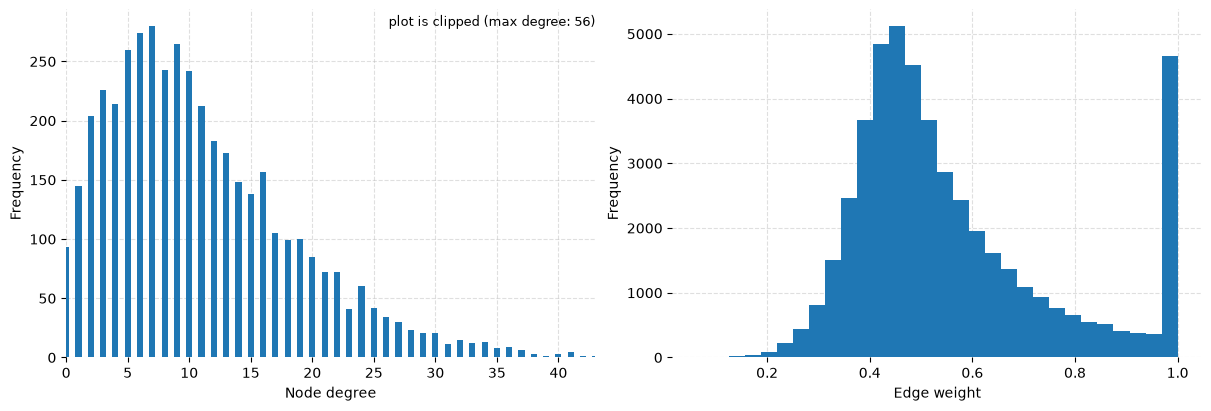

In [5]:
splt.graph_qc(loaded_graph)

In [6]:
degrees = np.asarray((loaded_graph != 0).sum(axis=0)).ravel()
pd.Series(
    {
        "active cells": int(loaded_graph.shape[0]),
        "isolated cells": int((degrees == 0).sum()),
        "median degree": float(np.median(degrees)),
        "min degree": int(degrees.min()),
        "max degree": int(degrees.max()),
    },
    name="graph coverage",
)

active cells      4360.0
isolated cells      93.0
median degree        9.0
min degree           0.0
max degree          56.0
Name: graph coverage, dtype: float64

In [7]:
degree_vs_qc = pd.DataFrame(
    {
        "degree": degrees,
        "RNA_nCounts": ds.cells.fetch("RNA_nCounts"),
        "RNA_nFeatures": ds.cells.fetch("RNA_nFeatures"),
    }
)
degree_vs_qc.corr(numeric_only=True)

,degree,RNA_nCounts,RNA_nFeatures
degree,1.000000,0.120199,0.099017
RNA_nCounts,0.120199,1.000000,0.915991
RNA_nFeatures,0.099017,0.915991,1.000000


In [8]:
state = ds.get_assay_state("RNA")
normalized_status = ds.inspect_artifact(state.normalized)
{
    "cell selection": state.cell_key,
    "feature selection": normalized_status.inputs["feature_selection"],
    "normalization": state.normalized,
    "reduction": state.reduction,
    "embedding initialization": state.embedding_initialization,
    "neighbours": state.neighbors,
    "connectivity": state.connectivity_map,
}

{'cell selection': 'I',
 'feature selection': {'type': 'artifact',
  'scope': 'assay',
  'kind': 'feature_selection',
  'artifact_id': '8587bd5afb4d2be6f98be9b16656ac00155d13a62379117b361c98c24d6bee00',
  'assay': 'RNA'},
 'normalization': ArtifactRef(assay='RNA', kind='normalized', artifact_id='41a6b1552d37...'),
 'reduction': ArtifactRef(assay='RNA', kind='reduction', artifact_id='df54e8ff5437...'),
 'embedding initialization': ArtifactRef(assay='RNA', kind='embedding_initialization', artifact_id='4b3b7124cccb...'),
 'neighbours': ArtifactRef(assay='RNA', kind='neighbors', artifact_id='ef9067be1ecb...'),
 'connectivity': ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='95ad5b58a217...')}

In [9]:
init_status = ds.inspect_artifact(initialization)
init_group = ds.load_artifact(initialization)
centers = np.asarray(init_group["cluster_centers"][:])
labels = np.asarray(init_group["cluster_labels"][:])
{
    "operation": init_status.operation,
    "n_centroids": init_status.parameters.get("n_centroids"),
    "cluster_centers": centers.shape,
    "n_labels": int(pd.Series(labels).nunique()),
    "complete": init_status.complete,
}

{'operation': 'build_embedding_initialization',
 'n_centroids': 100,
 'cluster_centers': (100, 15),
 'n_labels': 100,
 'complete': True}

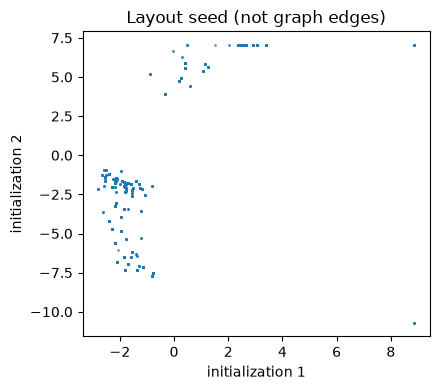

In [10]:
ini_coords = initial_embedding(centers, labels, 2)
figure, axis = plt.subplots(figsize=(4.5, 4))
axis.scatter(ini_coords[:, 0], ini_coords[:, 1], s=3, alpha=0.4, linewidths=0)
axis.set_xlabel("initialization 1")
axis.set_ylabel("initialization 2")
axis.set_title("Layout seed (not graph edges)")
figure.tight_layout()
figure

Training UMAP: 100 / 100 complete

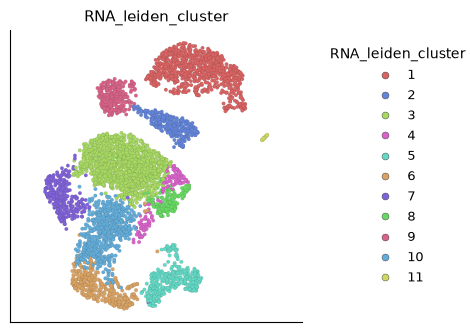

In [11]:
umap = ds.run_umap(
    n_epochs=100,
    parallel=True,
)
clusters = ds.run_leiden_clustering(resolution=0.5)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
)

In [12]:
ds.inspect_artifact(clusters).parameters

{'resolution': 0.5,
 'backend': 'igraph',
 'symmetric_graph': False,
 'graph_upper_only': False,
 'random_seed': 4444}

In [13]:
neighbors_k21 = ds.query_neighbors(
    ann_index,
    k=21,
    update_state=False,
)
graph_k21 = ds.build_connectivity_map(
    neighbors_k21,
    update_state=False,
)

current_state = ds.get_assay_state("RNA")
current_state.connectivity_map == graph, graph_k21 != graph

Identifying neighbors: 1 / 1 complete

(True, True)

In [14]:
loaded_graph_k21 = ds.load_graph(
    graph=graph_k21,
)
pd.Series(
    {
        "k=11 nnz": int(loaded_graph.nnz),
        "k=21 nnz": int(loaded_graph_k21.nnz),
    },
    name="edges",
)

k=11 nnz    47960
k=21 nnz    91560
Name: edges, dtype: int64

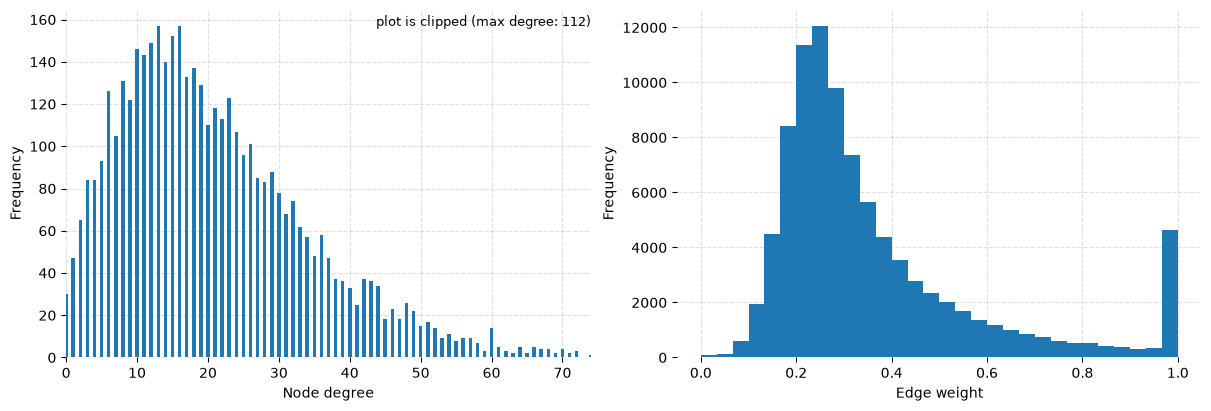

In [15]:
splt.graph_qc(loaded_graph_k21)

In [16]:
ds.run_leiden_clustering(
    graph=graph_k21,
    resolution=0.5,
    label="leiden_k21",
)

ArtifactRef(assay='RNA', kind='cluster_labels', artifact_id='1dfd3fc12591...')

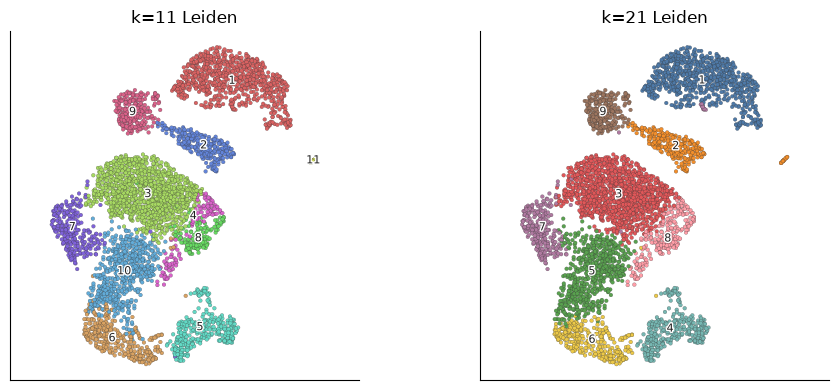

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, color_by, title in zip(
    axes,
    ("RNA_leiden_cluster", "RNA_leiden_k21"),
    ("k=11 Leiden", "k=21 Leiden"),
    strict=True,
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure

In [18]:
pd.crosstab(
    pd.Series(ds.cells.fetch("RNA_leiden_cluster"), name="k=11"),
    pd.Series(ds.cells.fetch("RNA_leiden_k21"), name="k=21"),
)

k=21,1,2,3,4,5,6,7,8,9
k=11,,,,,,,,,
1,781,0,0,0,0,0,11,0,0
2,0,261,0,0,1,0,0,0,1
3,0,0,1226,0,0,0,2,1,0
4,0,0,11,0,0,0,0,107,0
5,0,0,0,337,0,0,0,0,0
6,0,0,0,1,36,278,0,3,0
7,0,0,0,1,21,0,252,0,0
8,0,0,8,0,0,0,0,137,0
9,0,0,0,0,0,0,1,0,263
